# 13.4 일반 이미지 데이터 증강

In [ ]:
# PyTorch 및 이미지 처리 라이브러리
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version :", torch.__version__)               # 2.13.0+cpu
print("Torchvision version :", torchvision.__version__)     # 0.28.0+cpu

PyTorch version : 2.13.0+cpu
Torchvision version : 0.28.0+cpu


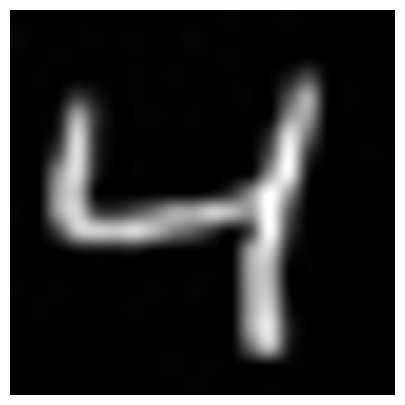

PIL image size : (224, 224)
img_tensor.shape : torch.Size([3, 224, 224])


In [2]:
# 2. 이미지 로드 및 전처리
img_path = "data/four.jpg"

src = Image.open(img_path).convert("RGB").resize((244, 244))
plt.figure(figsize=(5, 5))
plt.imshow(src)
plt.axis("off")
plt.show()

img = Image.open(img_path).convert("RGB").resize((224, 224))
print("PIL image size :", img.size)

# PyTorch는 이미지 데이터를 기본적으로 [C, H, W] 형태의 Tensor로 사용한다.
img_tensor = transforms.ToTensor()(img)
print("img_tensor.shape :", img_tensor.shape)


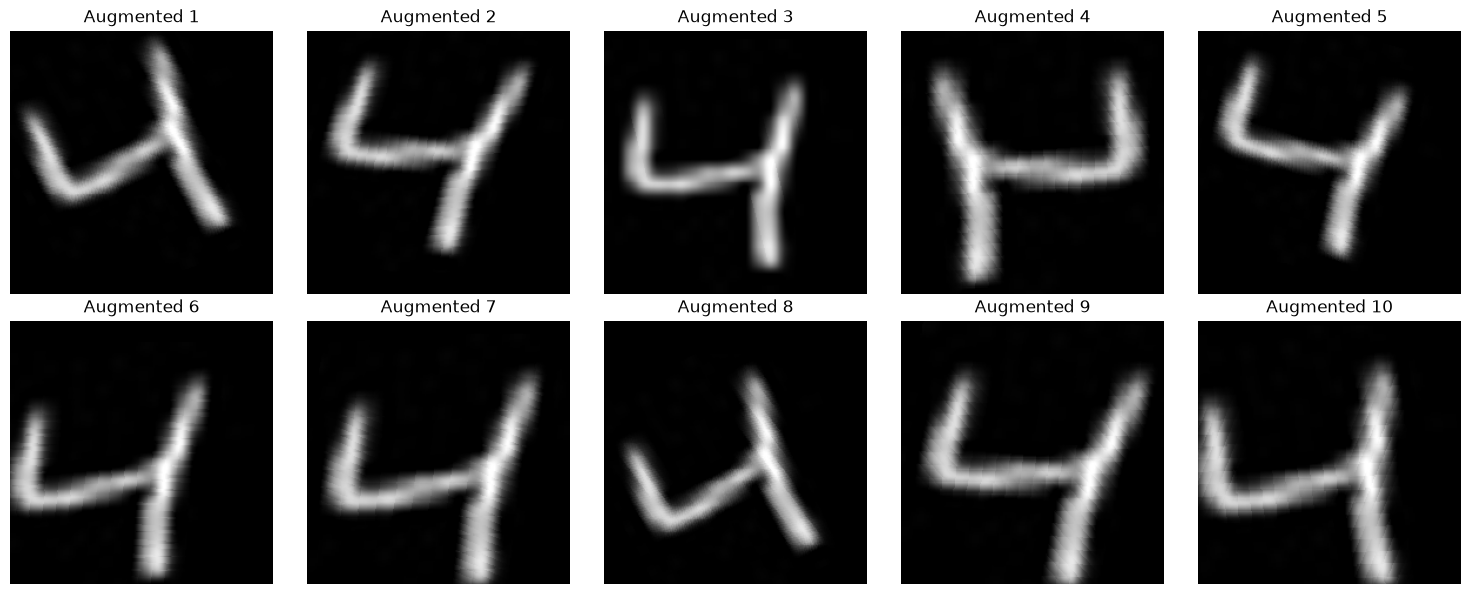

In [3]:
# 3. PyTorch 데이터 증강 설정
# Keras의 ImageDataGenerator에 대응하는 torchvision 변환이다.

augment_transform = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        shear=(-10, 10),
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
])

# 동일한 원본 이미지에 매번 랜덤 변환을 적용한다.
augmented_images = []

for _ in range(10):
    aug_img = augment_transform(img)
    augmented_images.append(aug_img)

# 4. 증강 이미지 10개 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, aug_img in enumerate(augmented_images):
    axes[i].imshow(aug_img)
    axes[i].axis("off")
    axes[i].set_title(f"Augmented {i+1}")

plt.tight_layout()
plt.show()


# 13.5  MNIST 데이터 증강

In [4]:
# MNIST 데이터셋 다운로드 및 로드
mnist_train_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

mnist_test_raw = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

print("학습 데이터 :", len(mnist_train_raw))
print("테스트 데이터 :", len(mnist_test_raw))

학습 데이터 : 60000
테스트 데이터 : 10000


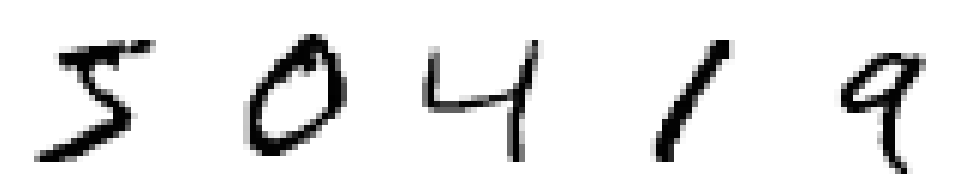

In [9]:
# 격자 형태로 이미지를 출력하는 함수
def draw_images(n, data):
    fig, ax = plt.subplots(
        1, n,
        sharex=True,
        sharey=True,
        figsize=(10, 2)
    )

    if n == 1:
        ax = [ax]

    for i in range(n):
        image = data[i]
        if torch.is_tensor(image):
            image = image.squeeze().cpu().numpy()

        ax[i].imshow(image, cmap="Greys")
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()

draw_images(5, mnist_train_raw.data)


In [10]:
# 데이터셋의 정보 요약
X_train = mnist_train_raw.data
y_train = mnist_train_raw.targets

X_test = mnist_test_raw.data
y_test = mnist_test_raw.targets

print("학습 데이터 :", X_train.shape, y_train.shape)
print("테스트 데이터 :", X_test.shape, y_test.shape)

print(f"학습 데이터의 최소값 : {X_train.min().item()}")
print(f"학습 데이터의 최대값 : {X_train.max().item()}")
print(f"학습 데이터의 평균값 : {X_train.float().mean().item():.4f}")
print(f"학습 데이터의 표준편차 : {X_train.float().std().item():.4f}")


학습 데이터 : torch.Size([60000, 28, 28]) torch.Size([60000])
테스트 데이터 : torch.Size([10000, 28, 28]) torch.Size([10000])
학습 데이터의 최소값 : 0
학습 데이터의 최대값 : 255
학습 데이터의 평균값 : 33.3184
학습 데이터의 표준편차 : 78.5675


In [14]:
# PyTorch의 ToTensor()를 사용하면
# uint8 [0, 255] 범위의 픽셀이 float [0, 1] 범위로 자동 변환된다.

to_tensor = transforms.ToTensor()
print(f'mnist_train_raw[0][0] : {type(mnist_train_raw[0][0])}')

sample_tensor = to_tensor(mnist_train_raw[0][0])

print("Tensor shape :", sample_tensor.shape)
print(f"최소값 : {sample_tensor.min().item():.4f}")
print(f"최대값 : {sample_tensor.max().item():.4f}")
print(f"평균값 : {sample_tensor.mean().item():.4f}")
print(f"표준편차 : {sample_tensor.std().item():.4f}")

mnist_train_raw[0][0] : <class 'PIL.Image.Image'>
Tensor shape : torch.Size([1, 28, 28])
최소값 : 0.0000
최대값 : 1.0000
평균값 : 0.1377
표준편차 : 0.3125


In [15]:
# 전체 학습 데이터의 평균과 표준편차를 이용한 표준화이다.
#PyTorch에서는 `transforms.Normalize(mean, std)`를 사용한다.

# MNIST 전체 학습 데이터의 평균과 표준편차 계산
mnist_float = X_train.float() / 255.0

mnist_mean = mnist_float.mean().item()
mnist_std = mnist_float.std().item()

print("MNIST mean :", mnist_mean)
print("MNIST std  :", mnist_std)

mnist_normalize = transforms.Normalize(
    mean=[mnist_mean],
    std=[mnist_std]
)

# ToTensor -> Normalize
normalized_transform = transforms.Compose([
    transforms.ToTensor(),
    mnist_normalize
])

sample_normalized = normalized_transform(mnist_train_raw[0][0])

print("정규화 후 shape :", sample_normalized.shape)
print(f"정규화 후 평균 : {sample_normalized.mean().item():.4f}")
print(f"정규화 후 표준편차 : {sample_normalized.std().item():.4f}")


MNIST mean : 0.13066047430038452
MNIST std  : 0.30810782313346863
정규화 후 shape : torch.Size([1, 28, 28])
정규화 후 평균 : 0.0228
정규화 후 표준편차 : 1.0144


# 13.6  다양한 데이터 증강

In [16]:
# MNIST 원본 데이터셋
mnist_base = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

def show_transform(transform, n=5, title="Augmented"):
    fig, axes = plt.subplots(1, n, figsize=(10, 2))

    if n == 1:
        axes = [axes]

    for i in range(n):
        image, label = mnist_base[i]
        augmented = transform(image)

        # Tensor [C,H,W] -> [H,W]
        augmented = augmented.squeeze().numpy()

        axes[i].imshow(augmented, cmap="Greys")
        axes[i].axis("off")
        axes[i].set_title(f"{title} {i+1}")

    plt.tight_layout()
    plt.show()

def show_grid_transform(transform, row=3, col=5, title="Augmented"):
    fig, axes = plt.subplots(row, col, figsize=(8, 5))
    axes = np.asarray(axes).reshape(row, col)

    for idx in range(row * col):
        image, label = mnist_base[idx]
        augmented = transform(image)
        augmented = augmented.squeeze().numpy()

        r = idx // col
        c = idx % col

        axes[r, c].imshow(augmented, cmap="Greys")
        axes[r, c].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


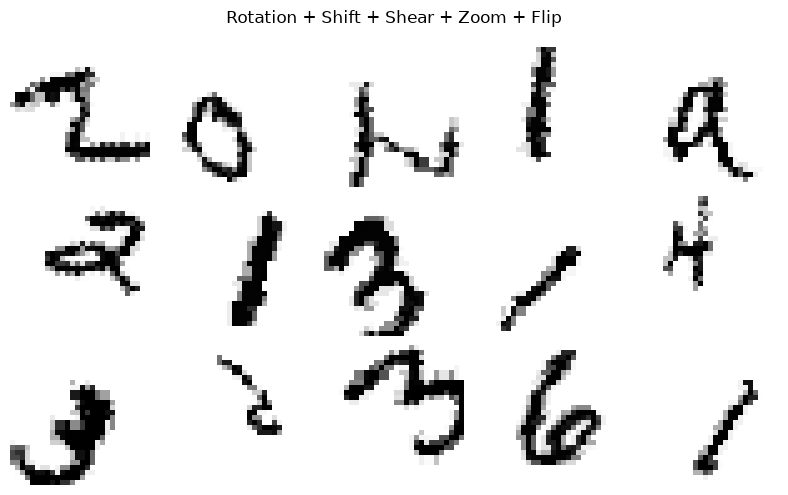

In [17]:
# 여러 변환을 한 번에 적용
transform = transforms.Compose([
    transforms.RandomRotation(40),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),
        shear=(-10, 10),
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5)
])

show_grid_transform(transform, title="Rotation + Shift + Shear + Zoom + Flip")


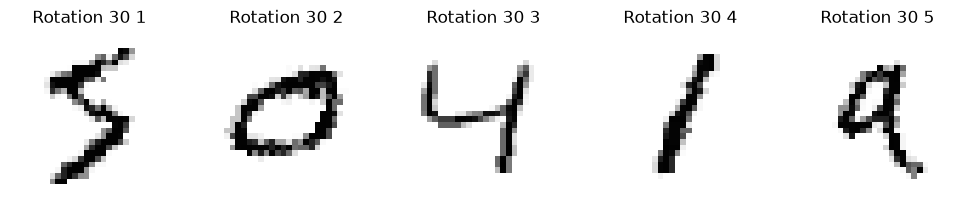

In [18]:
# 0도에서 30도 범위에서 랜덤하게 회전
transform = transforms.RandomRotation(degrees=30)
show_transform(transform, title="Rotation 30")

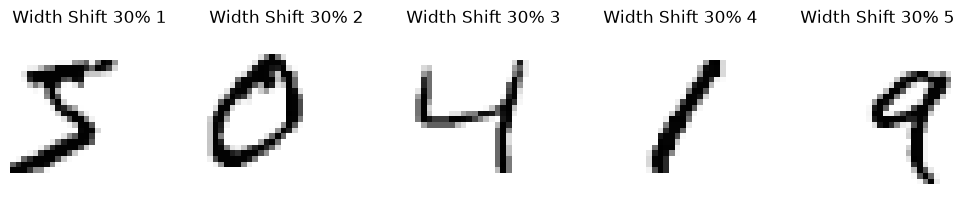

In [19]:
# 원래 이미지의 가로 방향을 최대 30%까지 랜덤 이동
transform = transforms.RandomAffine(
    degrees=0,
    translate=(0.3, 0)
)
show_transform(transform, title="Width Shift 30%")


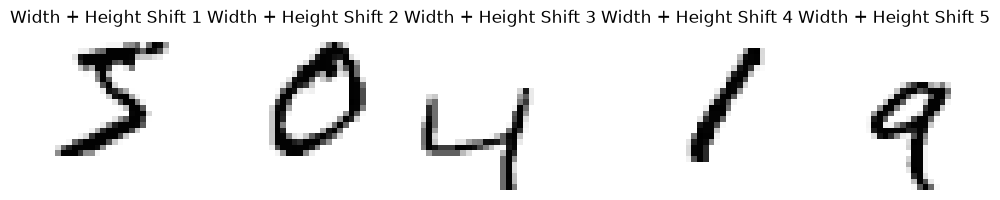

In [20]:
# 가로·세로 방향을 각각 최대 20%까지 랜덤 이동
shift = 0.2

transform = transforms.RandomAffine(
    degrees=0,
    translate=(shift, shift)
)

show_transform(transform, title="Width + Height Shift")

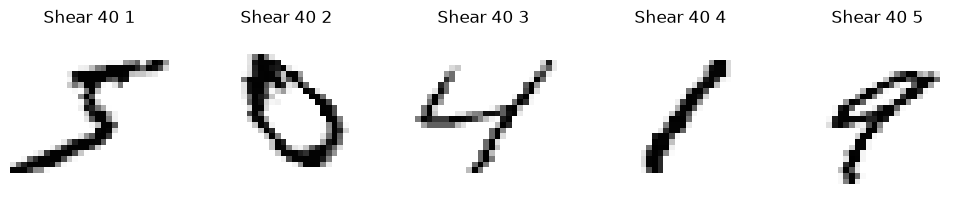

In [22]:
# 전단(Shear) 변환
# torchvision에서는 shear를 각도 단위로 지정한다.
shear = 40

transform = transforms.RandomAffine(
    degrees=0,
    shear=(-shear, shear)
)

show_transform(transform, title="Shear 40")
